<a href="https://colab.research.google.com/github/Thirupathi1356/Computer-Vision-/blob/main/Block_and_burst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

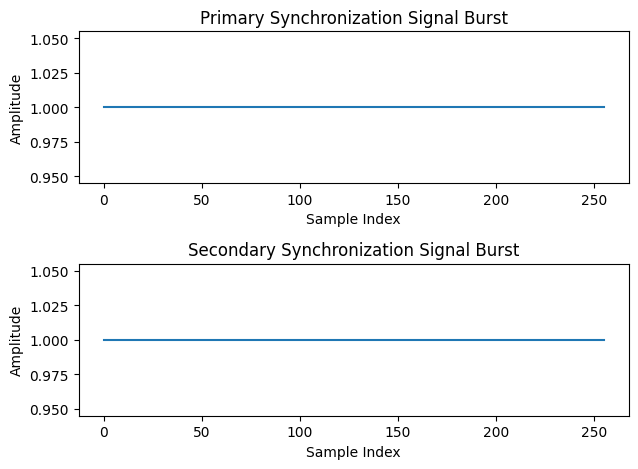

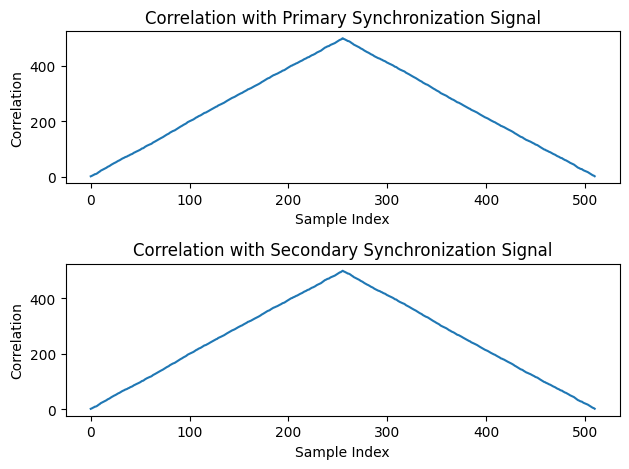

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Clear previous plots and variables (Python equivalent)
plt.close('all')
# For clearing variables, it's generally good practice to explicitly redefine or delete them if needed
# In a fresh cell execution, variables from previous runs are typically cleared.

# Parameters
fs = 30.72e6               # Sampling frequency (Hz)
Tc = 1/4.6e6               # Cyclic Prefix duration (s)
Ts = 1/fs                  # Sampling period (s)

# Generate Primary Synchronization Signal (PSS)
N_id_1 = 0                 # PSS identity (0 to 127)
n = np.arange(0, 128)      # 0 to 127 inclusive
pss = np.exp(1j * np.pi * N_id_1 * (n * (n + 1) / 2))

# Generate Secondary Synchronization Signal (SSS)
N_id_2 = 0                 # SSS identity (0 or 1)
m = np.arange(0, 32)       # 0 to 31 inclusive
sss = np.exp(1j * np.pi * N_id_2 * m)

# Generate Burst
n_burst = np.arange(0, 256) # 0 to 255 inclusive

# Ensure integer repetition
pss_repeat = np.ceil(len(n_burst) / len(pss)).astype(int)
sss_repeat = np.ceil(len(n_burst) / len(sss)).astype(int)

pss_sequence = np.tile(pss, pss_repeat)
sss_sequence = np.tile(sss, sss_repeat)

# Trim to match burst length
pss_sequence = pss_sequence[:len(n_burst)]
sss_sequence = sss_sequence[:len(n_burst)]

# Construct bursts
pss_burst = pss_sequence * np.exp(1j * 2 * np.pi * n_burst * Tc / Ts)
sss_burst = sss_sequence * np.exp(1j * 2 * np.pi * n_burst * Tc / Ts)

# Plot bursts
plt.figure()
plt.subplot(2,1,1)
plt.plot(n_burst, np.abs(pss_burst))
plt.title('Primary Synchronization Signal Burst')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(2,1,2)
plt.plot(n_burst, np.abs(sss_burst))
plt.title('Secondary Synchronization Signal Burst')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Add Noise (manual AWGN to avoid toolbox dependency)
signal = pss_burst + sss_burst
SNR_dB = 10

signal_power = np.mean(np.abs(signal)**2)
noise_power = signal_power / (10**(SNR_dB/10))
noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j*np.random.randn(*signal.shape))

received_signal = signal + noise

# Correlation with PSS
# xcorr in numpy/scipy gives a full correlation, need to adjust for specific signal processing use cases
# For simple cross-correlation, numpy.correlate can be used.
# If xcorr from MATLAB is needed, it's typically implemented as convolution or FFT-based correlation.
correlation_pss = np.correlate(received_signal, pss_burst, mode='full')

plt.figure()
plt.subplot(2,1,1)
plt.plot(np.abs(correlation_pss))
plt.title('Correlation with Primary Synchronization Signal')
plt.xlabel('Sample Index')
plt.ylabel('Correlation')

# Correlation with SSS
correlation_sss = np.correlate(received_signal, sss_burst, mode='full')

plt.subplot(2,1,2)
plt.plot(np.abs(correlation_sss))
plt.title('Correlation with Secondary Synchronization Signal')
plt.xlabel('Sample Index')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()